In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

Question 01

In [ ]:
# Load image
runway_img = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)
assert runway_img is not None, "Image not found"   

runway_img_norm = runway_img / 255.0 

In [3]:
# --- (a) Gamma Correction with gamma = 0.5 (Encoding/Brightening)
gamma_05 = np.power(runway_img_norm, 0.5)
gamma_05_img = (gamma_05 * 255).astype(np.uint8) # Convert back to 0–255
cv.imwrite('ques1/gamma_0_5.png', gamma_05_img)

# --- (b) Gamma Correction with gamma = 2.0 (Decoding/Darkening)
gamma_2 = np.power(runway_img_norm, 2)
gamma_2_img = (gamma_2 * 255).astype(np.uint8)
cv.imwrite('ques1/gamma_2.png', gamma_2_img)

True

In [ ]:
# --- (c) Contrast Stretching (Piecewise Linear) ---
r1, r2 = 0.2, 0.8
contrast = np.zeros_like(runway_img_norm)

# Apply piecewise transformation
contrast[runway_img_norm < r1] = 0
contrast[(runway_img_norm >= r1) & (runway_img_norm <= r2)] = \
    (runway_img_norm[(runway_img_norm >= r1) & (runway_img_norm <= r2)] - r1) / (r2 - r1)
contrast[runway_img_norm > r2] = 1

contrast_img = (contrast * 255).astype(np.uint8)

cv.imwrite('ques1/contrast_stretch.png', contrast_img)

True

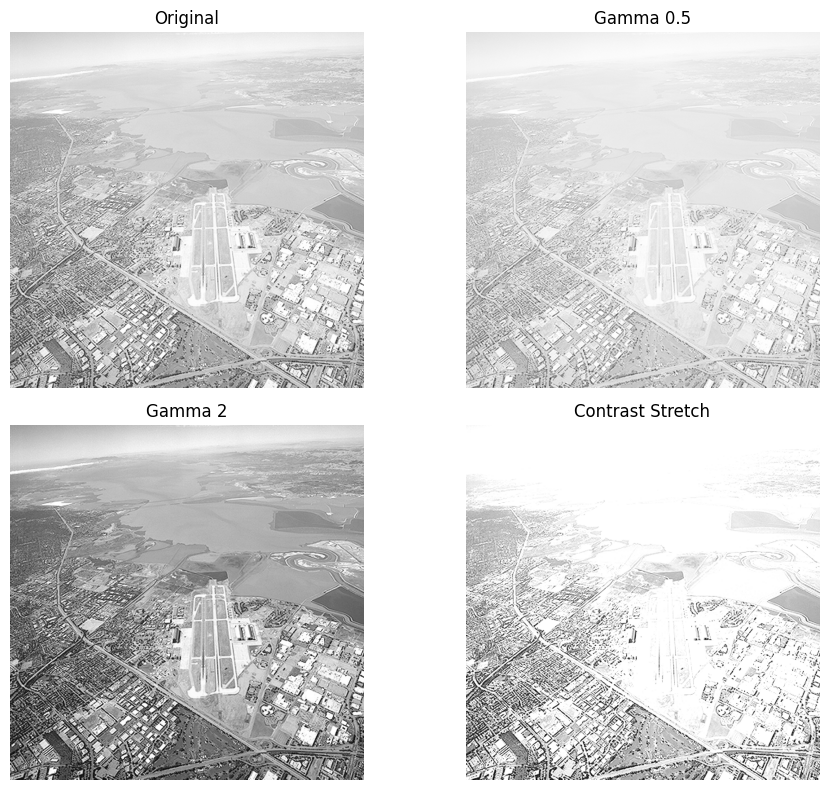

In [7]:
# --- Visualization ---
titles = ['Original', 'Gamma 0.5', 'Gamma 2', 'Contrast Stretch']
images = [runway_img, gamma_05_img, gamma_2_img, contrast_img]

plt.figure(figsize=(10,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()